# Synthetic Time Series Generators

`metaforecast.synth` ships 18 generators in three groups.

Pure synthetic methods create series from scratch (no source data). Semi-synthetic methods build new series from a source dataset by mixing or resampling. Transformers rewrite each source series by applying some transformation like jittering while keeping the same timestamps.

This notebook shows one call and one plot per method. Transformers and Grasynda overlay a source series with the generated copy, as in the offline augmentation tutorial. TSMixup and DBA mix several series from the pool, so those plots show only the generated sample. Pure generators are plotted on their own.

The steps are as follows.

1. Load a small M3 monthly pool and isolate series `M1`.
2. Draw one series from each pure generator.
3. Apply each semi-synthetic generator to the pool.
4. Apply each transformer to `M1` (HomomorphicAugmentation also needs a style series from the pool).


In [1]:
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.random.seed(0)

If necessary, install the package using pip:


In [ ]:
# !pip install metaforecast

## 1. Data preparation

M3 monthly from `datasetsforecast` is the source pool. Eight series are enough for mixup, DBA, and homomorphic style transfer. Overlay plots use `M1` only when the method has a 1-1 source series (Grasynda and the transformers).


In [11]:
from datasetsforecast.m3 import M3

df, *_ = M3.load(".", group="Monthly")
df["unique_id"] = df["unique_id"].astype(str)
df["ds"] = pd.to_datetime(df["ds"])

uids = df["unique_id"].drop_duplicates().head(20).tolist()
pool_df = df[df["unique_id"].isin(uids)].copy()
m1_df = pool_df.query('unique_id == "M1"').copy()

print(len(uids), "series in the pool;", len(m1_df), "observations in M1")
m1_df.head()


20 series in the pool; 68 observations in M1


,unique_id,ds,y
0,M1,1990-01-31,2640.0
1,M1,1990-02-28,2640.0
2,M1,1990-03-31,2160.0
3,M1,1990-04-30,4200.0
4,M1,1990-05-31,3360.0


Plot helpers. `plot_overlay` matches the original-vs-synthetic figure in the SeasonalMBB tutorial. `plot_one` is for series that have no source counterpart.


In [4]:
def y_by_uid(frame, uid=None):
    if uid is None:
        uid = frame["unique_id"].iloc[0]
    return frame.query("unique_id == @uid").set_index("ds")["y"]


def synth_uid(frame, orig_uid=None, alias=None):
    ids = frame["unique_id"].astype(str)
    if orig_uid is not None and alias is not None:
        hits = ids[ids.str.startswith(f"{orig_uid}_{alias}")]
        if len(hits):
            return hits.iloc[0]
    return ids.iloc[0]


def plot_overlay(orig, synth, title, synth_label):
    ax = orig.plot(figsize=(12, 4), label="original")
    synth.plot(ax=ax, label=synth_label)
    ax.legend()
    ax.set_title(title)


def plot_one(series, title, label="synthetic"):
    ax = series.plot(figsize=(12, 4), label=label)
    ax.legend()
    ax.set_title(title)


obs = y_by_uid(m1_df, "M1")

## 2. Pure synthetic generators

These classes implement `transform(n_series)`. They do not read `pool_df`. Frequency is monthly (`ME`) and each example has 120 observations so the plots stay readable.


### KernelSynth

Combines random kernels from a bank (RBF, periodic, polynomial, noise) with a Gaussian process. `max_kernels` caps how many kernels are mixed.


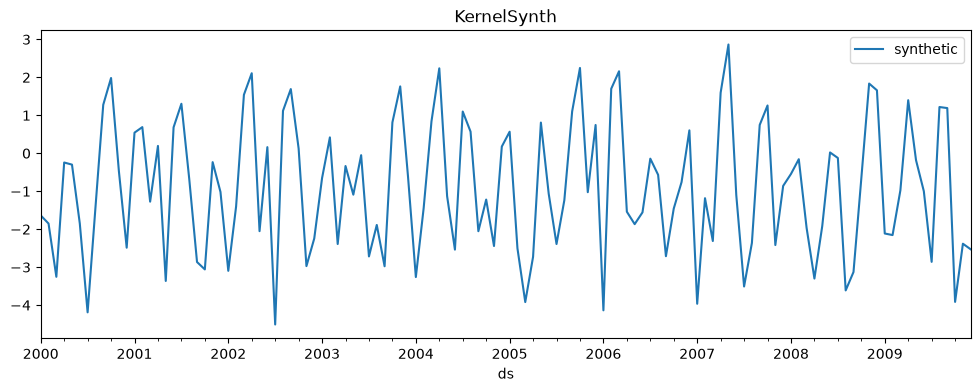

In [5]:
from metaforecast.synth import KernelSynth

tsgen = KernelSynth(max_kernels=5, n_obs=120, freq="ME")
synth_df = tsgen.transform(n_series=1)
plot_one(y_by_uid(synth_df), "KernelSynth")


### SeasonalTrend

Fourier seasonality, a deterministic trend, and an AR residual, mixed with Dirichlet weights. `difficulty_mode` shifts how much energy goes to trend and noise.


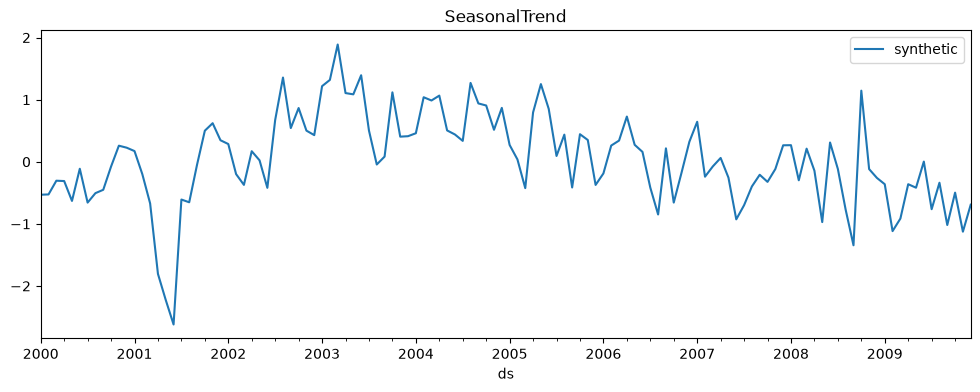

In [6]:
from metaforecast.synth import SeasonalTrend

tsgen = SeasonalTrend(n_obs=120, freq="ME", difficulty_mode="medium", seed=0)
synth_df = tsgen.transform(n_series=1)
plot_one(y_by_uid(synth_df), "SeasonalTrend")


### NonstationaryRegime

Markov-switching AR regimes plus a stochastic trend. Useful when you want structural breaks in the synthetic sample.


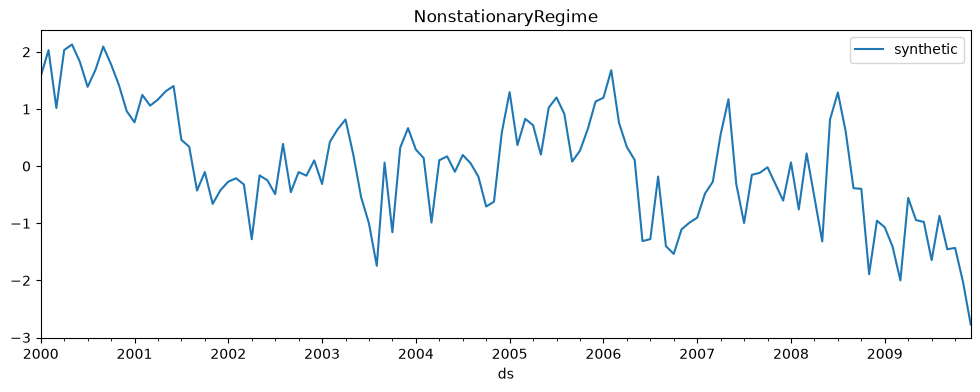

In [7]:
from metaforecast.synth import NonstationaryRegime

tsgen = NonstationaryRegime(n_obs=120, freq="ME", difficulty_mode="medium", seed=0)
synth_df = tsgen.transform(n_series=1)
plot_one(y_by_uid(synth_df), "NonstationaryRegime")


### LongMemory

ARFIMA or fractional Brownian motion, optionally with a light seasonal overlay. Autocorrelations decay slowly.


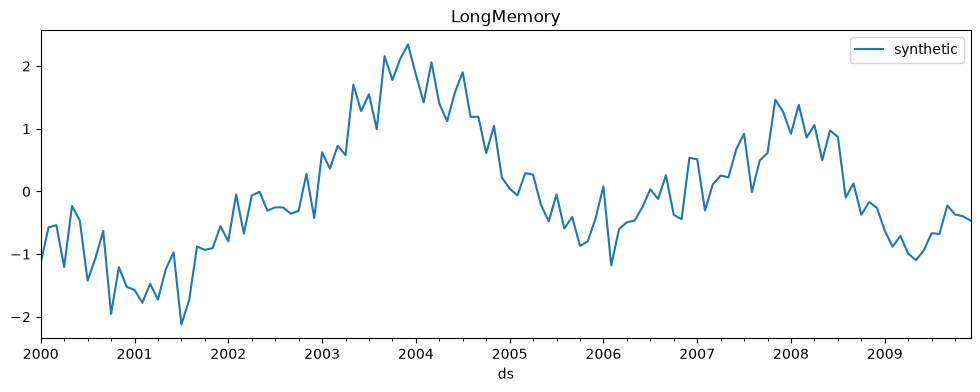

In [8]:
from metaforecast.synth import LongMemory

tsgen = LongMemory(n_obs=120, freq="ME", difficulty_mode="medium", seed=0)
synth_df = tsgen.transform(n_series=1)
plot_one(y_by_uid(synth_df), "LongMemory")


### VolatilityEvents

Mean AR(1), GARCH(1,1) volatility clustering, and Hawkes spikes. The plot is one sample, not a transform of M1.


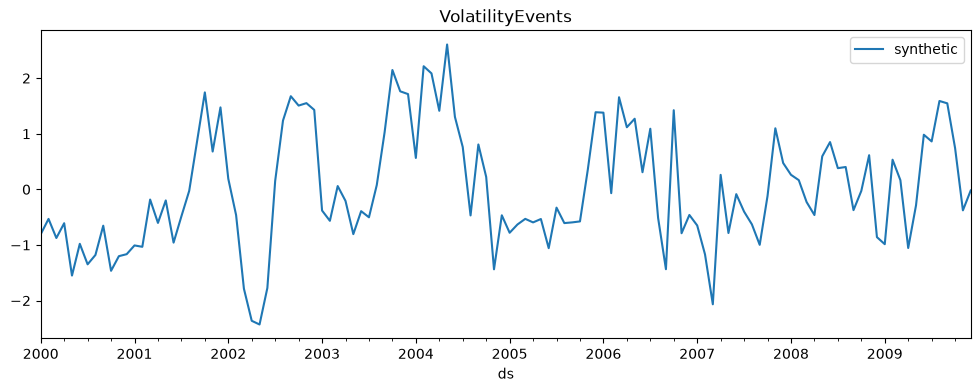

In [9]:
from metaforecast.synth import VolatilityEvents

tsgen = VolatilityEvents(n_obs=120, freq="ME", difficulty_mode="medium", seed=0)
synth_df = tsgen.transform(n_series=1)
plot_one(y_by_uid(synth_df), "VolatilityEvents")


## 3. Semi-synthetic generators

These classes implement `transform(df, n_series)`. The pool is the source. TSMixup and DBA are two ways of mixing several series from that pool into a new series. Grasynda learns a quantile-transition graph from one source series, so the plot overlays M1 with its generated copy.


### TSMixup

Weighted average of up to `max_n_uids` source series. Length is drawn between `min_len` and `max_len`.


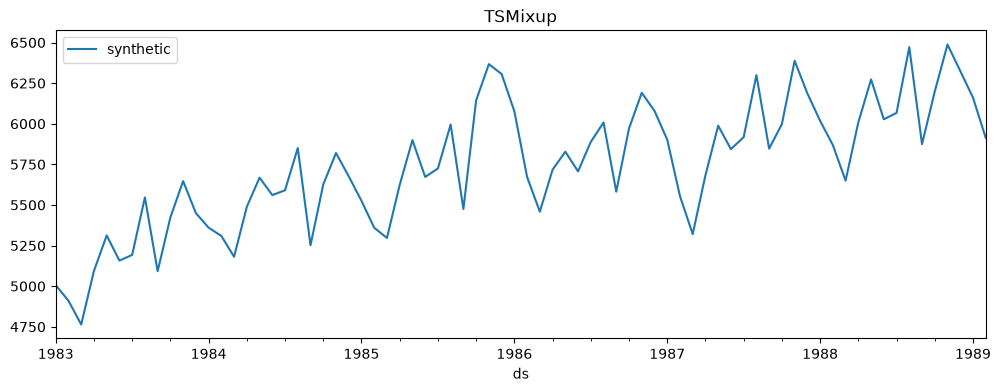

In [20]:
from metaforecast.synth import TSMixup

# keep re-running this cell to get a different sample
tsgen = TSMixup(max_n_uids=6, min_len=48, max_len=96)
synth_df = tsgen.transform(pool_df, n_series=1)
plot_one(y_by_uid(synth_df), "TSMixup")


### DBA

DTW barycentric average of a random subset of the pool. `max_n_uids` is the largest subset size.


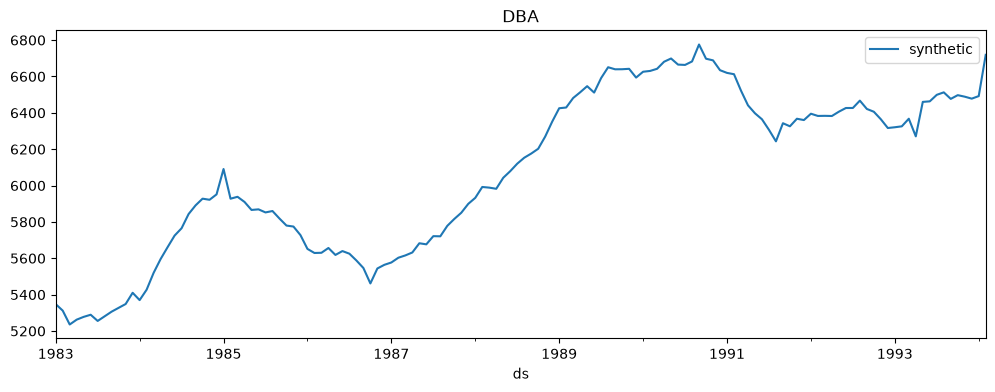

In [ ]:
from metaforecast.synth import DBA

tsgen = DBA(max_n_uids=4, max_iter=10)
# keep re-running this cell to get a different sample
synth_df = tsgen.transform(pool_df, n_series=1)
plot_one(y_by_uid(synth_df), "DBA")

### Grasynda

STL on each source series, then a quantile Markov graph on the remainder (default). `period=12` matches monthly seasonality. Here the source is M1 only, so the overlay is a true pair.


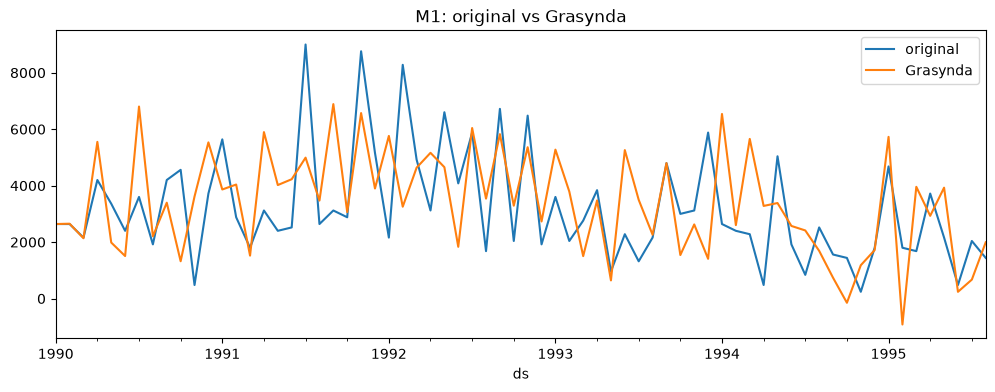

In [22]:
from metaforecast.synth import Grasynda

tsgen = Grasynda(period=12, n_quantiles=20)
synth_df = tsgen.transform(m1_df, n_series=1)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs Grasynda", "Grasynda")

## 4. Transformers

These classes implement `transform(df)` and return one synthetic copy per input series, with a new `unique_id` such as `M1_JITTER0`. Unless noted, the input is M1 alone.


### Jittering

Adds Gaussian noise with standard deviation `sigma` times the series scale.


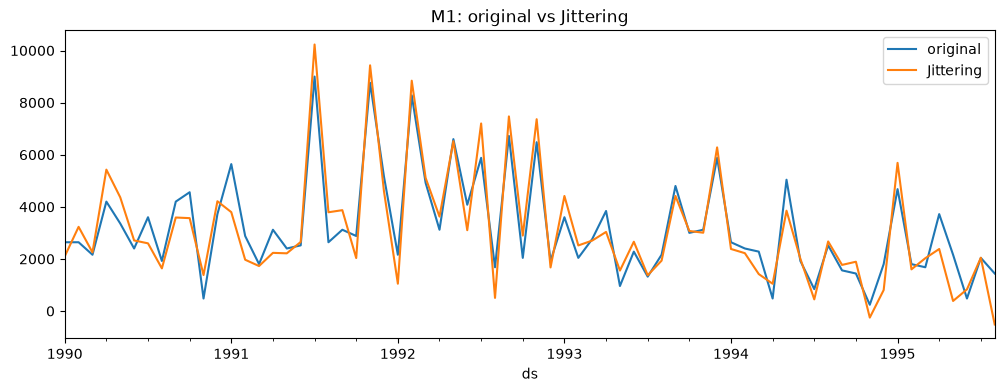

In [24]:
from metaforecast.synth import Jittering

tsgen = Jittering(sigma=0.35)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs Jittering", "Jittering")


### Scaling

Multiplies each point by a random factor centred at 1. `sigma` is the spread of those factors.


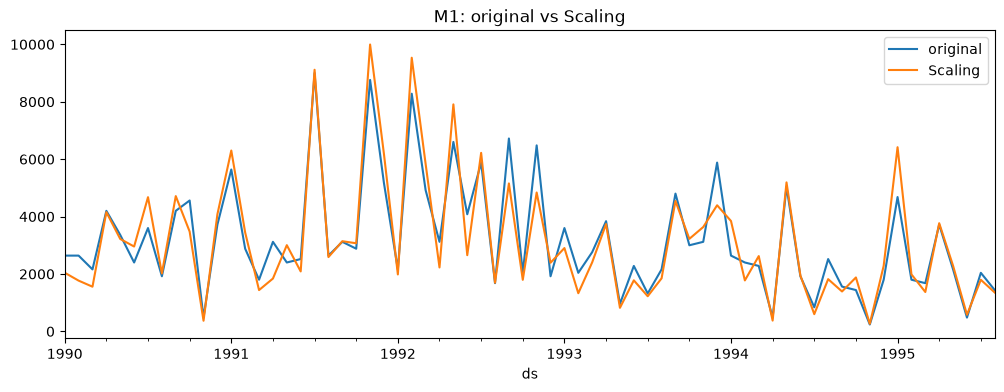

In [25]:
from metaforecast.synth import Scaling

tsgen = Scaling(sigma=0.2)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs Scaling", "Scaling")


### MagnitudeWarping

Smooth amplitude changes from a cubic spline with `knot` control points.


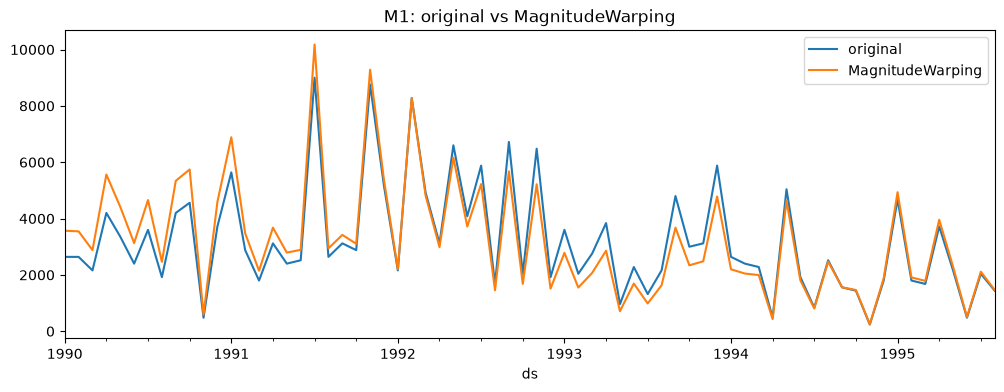

In [26]:
from metaforecast.synth import MagnitudeWarping

tsgen = MagnitudeWarping(sigma=0.3, knot=4)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs MagnitudeWarping", "MagnitudeWarping")


### TimeWarping

Smoothly distorts the time axis, then interpolates values back onto the original grid.


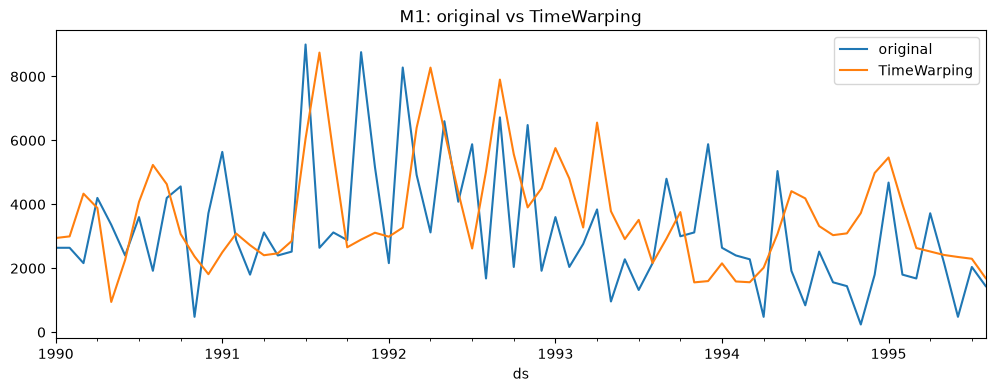

In [27]:
from metaforecast.synth import TimeWarping

tsgen = TimeWarping(sigma=0.2, knot=4)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs TimeWarping", "TimeWarping")


### SeasonalMBB

STL, then a moving-block bootstrap on the residual with block length `seas_period`. Trend and seasonality stay put.


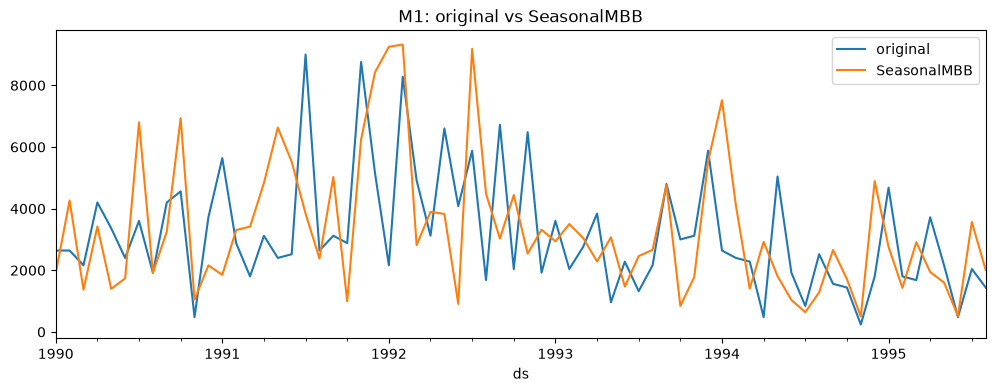

In [28]:
from metaforecast.synth import SeasonalMBB

tsgen = SeasonalMBB(seas_period=12)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs SeasonalMBB", "SeasonalMBB")


### AmplitudeModulation

Multiplies the series by a piecewise-linear trend with a random number of changepoints (at most `max_changepoints`).


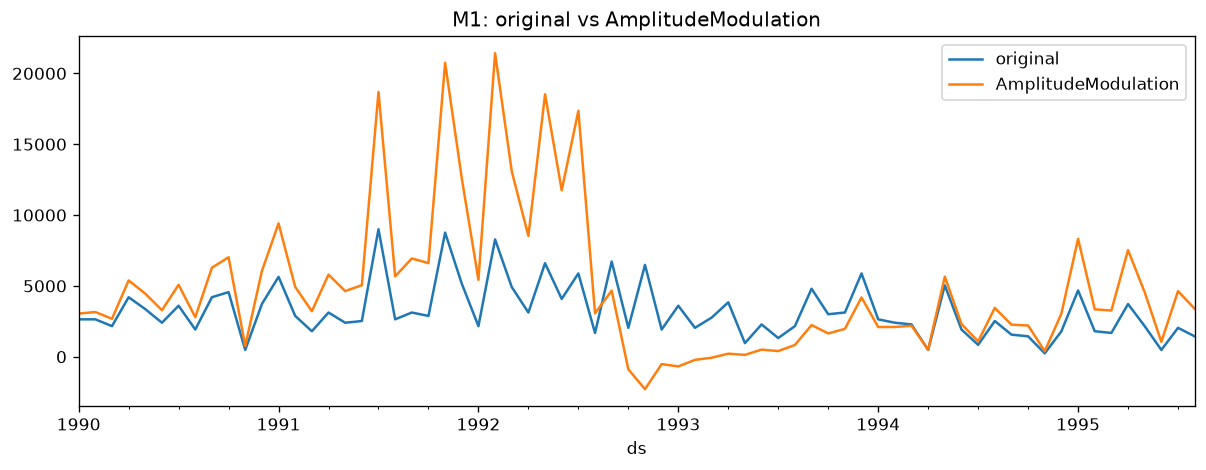

In [ ]:
from metaforecast.synth import AmplitudeModulation

tsgen = AmplitudeModulation(max_changepoints=4)
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs AmplitudeModulation", "AmplitudeModulation")

### CensorAugmentation

Clips the series from above or below at a random quantile. That is the whole method; some draws look mild, others flatten a large share of points.


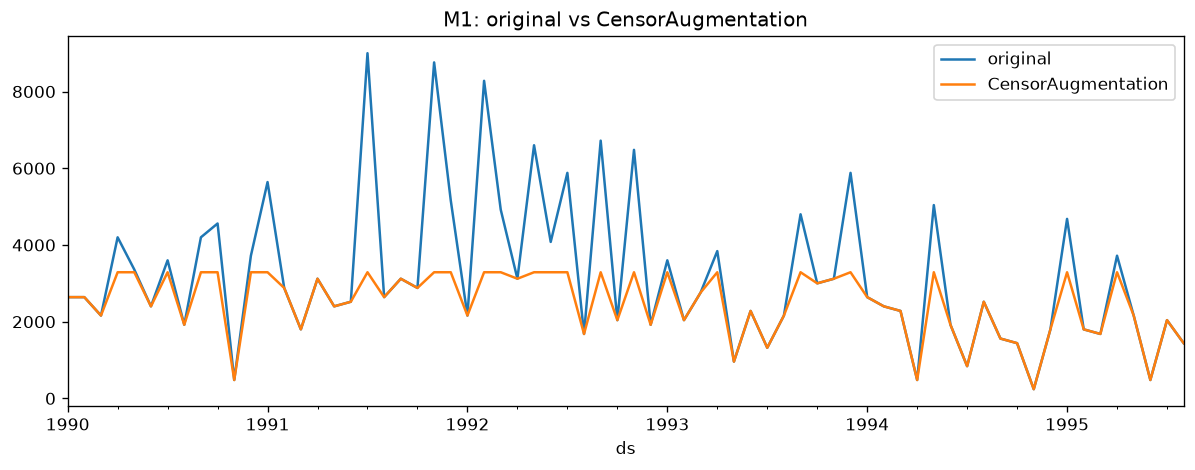

In [40]:
from metaforecast.synth import CensorAugmentation

tsgen = CensorAugmentation()
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs CensorAugmentation", "CensorAugmentation")


### SpikeInjection

Adds a tiled periodic spike pattern (tophat, RBF, or linear kernels). Amplitudes scale with the series standard deviation by default.


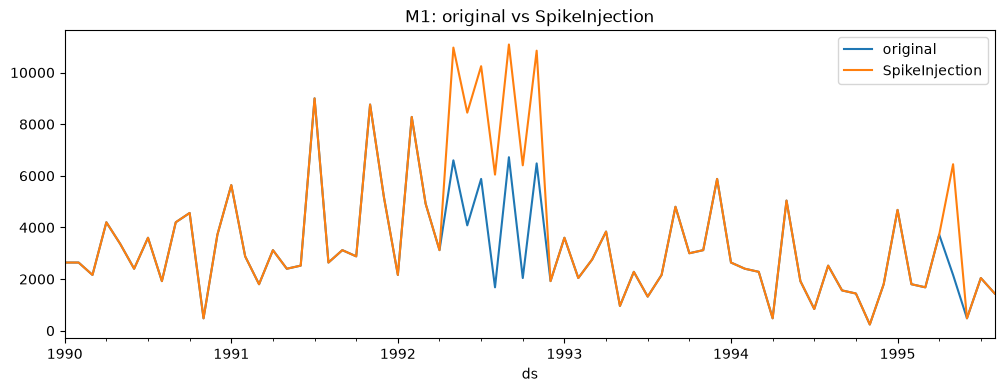

In [39]:
from metaforecast.synth import SpikeInjection

tsgen = SpikeInjection()
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs SpikeInjection", "SpikeInjection")


### DominantShuffle

FFT, shuffle the `k` largest-magnitude frequencies, inverse FFT. Spectral energy stays; the dominant modes are rearranged.


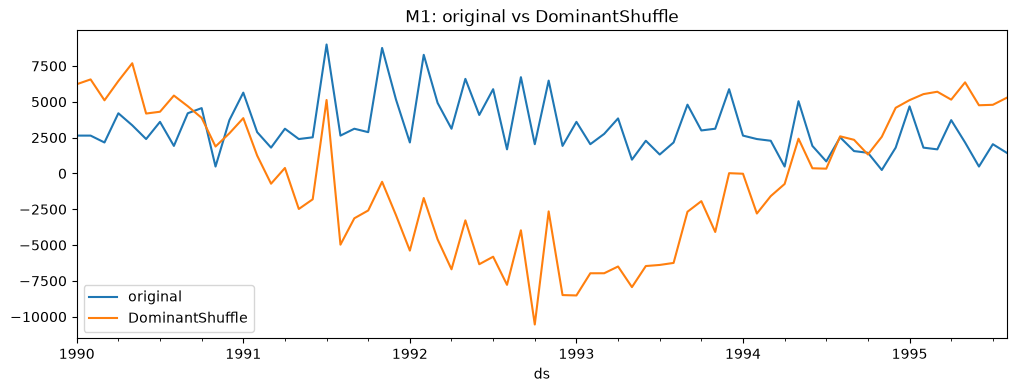

In [ ]:
from metaforecast.synth import DominantShuffle

tsgen = DominantShuffle(k=5)
# keep re-running this cell to get a different sample
synth_df = tsgen.transform(m1_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs DominantShuffle", "DominantShuffle")


### HomomorphicAugmentation

Decomposes each series into phase, spectral envelope, and harmonics, then recombines with a style series drawn from the same dataset. The input is the eight-series pool so a style series exists; the plot is M1 against its HCA copy.


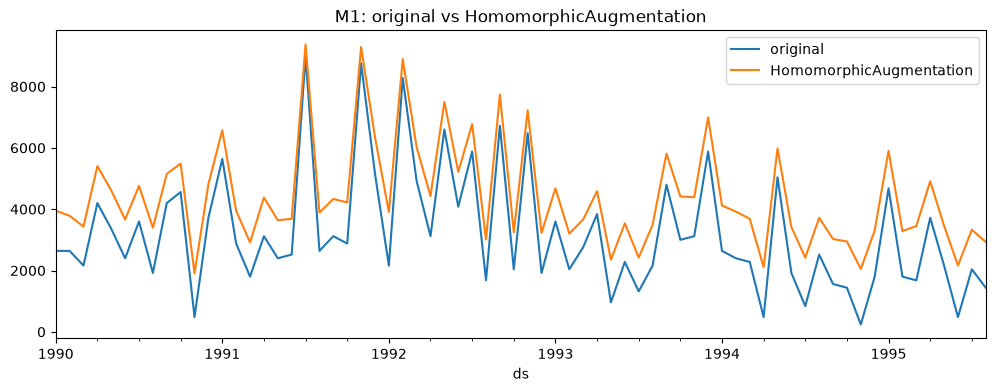

In [ ]:
from metaforecast.synth import HomomorphicAugmentation

tsgen = HomomorphicAugmentation(delta=0.2, lambda_=.1)
synth_df = tsgen.transform(pool_df)
uid = synth_uid(synth_df, orig_uid="M1", alias=tsgen.alias)
plot_overlay(obs, y_by_uid(synth_df, uid), "M1: original vs HomomorphicAugmentation", "HomomorphicAugmentation")
